# review_score_mean 상관분석 및 물류 변수 통계검정

이 노트북은 `review_score_mean`에 영향을 줄 가능성이 있는 요소를 탐색하기 위해 주문 단위 분석 테이블을 만들고, 수치형 변수와의 상관계수를 계산합니다.

특히 물류 관련 변수는 별도로 표시하고, 물류 변수와 `review_score_mean` 사이의 관계가 통계적으로 유의한지 검정합니다.

주의: 원본 processed CSV는 주문-상품 단위입니다. `review_score_mean`은 주문 단위 값이라 item-level 행을 그대로 쓰면 다품목 주문이 반복 가중됩니다. 따라서 여기서는 `order_id` 기준으로 주문 단위 분석 테이블을 만든 뒤 분석합니다.

## 1. 라이브러리와 데이터 경로

In [1]:
from pathlib import Path

from itertools import combinations

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:,.4f}".format)

def fdr_bh(p_values):
    """Benjamini-Hochberg FDR adjusted p-values."""
    p = np.asarray(p_values, dtype=float)
    adjusted = np.full_like(p, np.nan, dtype=float)
    valid = np.isfinite(p)
    if valid.sum() == 0:
        return adjusted
    p_valid = p[valid]
    n = len(p_valid)
    order = np.argsort(p_valid)
    ranked = p_valid[order]
    adj_ranked = ranked * n / np.arange(1, n + 1)
    adj_ranked = np.minimum.accumulate(adj_ranked[::-1])[::-1]
    adj_ranked = np.clip(adj_ranked, 0, 1)
    valid_idx = np.where(valid)[0]
    adjusted[valid_idx[order]] = adj_ranked
    return adjusted

ROOT = Path.cwd()
while not (ROOT / "data" / "processed").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "processed" / "olist_delivered_item_level_cleaned_errors.csv"
if not DATA_PATH.exists():
    DATA_PATH = ROOT / "data" / "processed" / "olist_delivered_item_level.csv"

DATA_PATH

WindowsPath('c:/team-oldest-olist-analysis/data/processed/olist_delivered_item_level_cleaned_errors.csv')

## 2. 데이터 로드

`review_score_mean`과 배송 성과를 함께 볼 수 있도록 배송 완료 데이터만 사용합니다. 전처리 README 기준으로 `olist_delivered_item_level_cleaned_errors.csv`가 있으면 오류 보정본을 우선 사용합니다.

In [2]:
DATE_COLS = [
    "shipping_limit_date",
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "purchase_date",
    "review_creation_min",
    "review_answer_max",
]

df = pd.read_csv(
    DATA_PATH,
    parse_dates=[col for col in DATE_COLS if col in pd.read_csv(DATA_PATH, nrows=0).columns],
)

required_cols = ["order_id", "review_score_mean"]
missing_required = [col for col in required_cols if col not in df.columns]
if missing_required:
    raise ValueError(f"필수 컬럼이 없습니다: {missing_required}")

df = df[df["review_score_mean"].notna()].copy()

print(f"data path: {DATA_PATH}")
print(f"item-level rows: {len(df):,}")
print(f"orders: {df['order_id'].nunique():,}")
df.head()

data path: c:\team-oldest-olist-analysis\data\processed\olist_delivered_item_level_cleaned_errors.csv
item-level rows: 107,762
orders: 94,443


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,item_total,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_date,purchase_year,purchase_month,purchase_weekday,purchase_hour,anomaly_carrier_before_approved,anomaly_customer_before_carrier,anomaly_missing_required_delivery_date,anomaly_flag,delivery_days_all,delivery_days_clean,is_late,is_delivered,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_state_kor,customer_region,customer_geo_lat,customer_geo_lng,customer_geo_city,customer_geo_state,seller_zip_code_prefix,seller_city,seller_state,seller_state_kor,seller_region,seller_geo_lat,seller_geo_lng,seller_geo_city,seller_geo_state,seller_state_geo_mismatch,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,payment_value_total,payment_installments_max,payment_type_nunique,payment_types,review_score_mean,review_count,review_creation_min,review_answer_max,seller_customer_same_state,delivery_route,is_seller_geo_unreliable
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9000,13.2900,72.1900,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,2017-09-13,2017,9,Wednesday,8,False,False,False,0,7,7,False,True,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,리우데자네이루주,남동부,-21.7628,-41.3096,campos dos goytacazes,RJ,27277,volta redonda,SP,상파울루주,남동부,-22.4970,-44.1275,volta redonda,RJ,True,cool_stuff,58.0000,598.0000,4.0000,650.0000,28.0000,9.0000,14.0000,cool_stuff,72.1900,2.0000,1.0000,credit_card,5.0000,1.0000,2017-09-21 00:00:00,2017-09-22 10:57:03,False,SP -> RJ,True
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9000,19.9300,259.8300,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,2017-04-26,2017,4,Wednesday,10,False,False,False,0,16,16,False,True,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,상파울루주,남동부,-20.2205,-50.9034,santa fe do sul,SP,3471,sao paulo,SP,상파울루주,남동부,-23.5651,-46.5186,sao paulo,SP,False,pet_shop,56.0000,239.0000,2.0000,"30,000.0000",50.0000,30.0000,40.0000,pet_shop,259.8300,3.0000,1.0000,credit_card,4.0000,1.0000,2017-05-13 00:00:00,2017-05-15 11:34:13,True,SP -> SP,False
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0000,17.8700,216.8700,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,2018-01-14,2018,1,Sunday,14,False,False,False,0,7,7,False,True,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,미나스제라이스주,남동부,-19.8703,-44.5933,para de minas,MG,37564,borda da mata,MG,미나스제라이스주,남동부,-22.2626,-46.1711,borda da mata,MG,False,moveis_decoracao,59.0000,695.0000,2.0000,"3,050.0000",33.0000,13.0000,33.0000,furniture_decor,216.8700,5.0000,1.0000,credit_card,5.0000,1.0000,2018-01-23 00:00:00,2018-01-23 16:06:31,True,MG -> MG,False
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.9900,12.7900,25.7800,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,2018-08-08,2018,8,Wednesday,10,False,False,False,0,6,6,False,True,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,상파울루주,남동부,-23.0899,-46.6117,atibaia,SP,14403,franca,SP,상파울루주,남동부,-20.5536,-47.3874,franca,SP,False,perfumaria,42.0000,480.0000,1.0000,200.0000,16.0000,10.0000,15.0000,perfumery,25.7800,

## 3. 주문 단위 분석 테이블 생성

상관분석의 기준 단위는 주문입니다. 주문-상품 단위의 가격, 운임, 상품 크기/무게는 주문 단위로 합계 또는 평균을 만들고, 주문 단위로 반복되는 컬럼은 첫 번째 값을 사용합니다.

추가로 물류 분석에 유용한 파생 변수를 만듭니다.

- `handling_time_days`: 결제 승인 후 배송사 인계까지 걸린 일수
- `carrier_to_customer_days`: 배송사 인계 후 고객 수령까지 걸린 일수
- `estimated_delivery_days`: 주문 시점부터 예상 배송일까지 약속된 배송 기간
- `delivery_vs_estimated_days`: 실제 고객 수령일 - 예상 배송일. 양수면 지연
- `seller_customer_distance_km`: 판매자-고객 좌표 기반 직선거리
- `freight_ratio`: 주문 총액 중 운임 비중

In [3]:
def first_existing(cols):
    return [col for col in cols if col in df.columns]


first_cols = first_existing([
    "review_score_mean",
    "review_count",
    "order_status",
    "purchase_year",
    "purchase_month",
    "purchase_hour",
    "delivery_days_clean",
    "delivery_days_all",
    "is_late",
    "is_delivered",
    "seller_customer_same_state",
    "seller_state_geo_mismatch",
    "is_seller_geo_unreliable",
    "customer_zip_code_prefix",
    "seller_zip_code_prefix",
    "customer_geo_lat",
    "customer_geo_lng",
    "seller_geo_lat",
    "seller_geo_lng",
    "payment_value_total",
    "payment_installments_max",
    "payment_type_nunique",
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "shipping_limit_date",
    "review_creation_min",
    "review_answer_max",
    "seller_state",
    "customer_state",
    "seller_region",
    "customer_region",
    "delivery_route",
])

agg_spec = {col: "first" for col in first_cols}

for col in first_existing(["price", "freight_value", "item_total"]):
    agg_spec[col] = "sum"

for col in first_existing([
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",
    "product_photos_qty",
    "product_name_lenght",
    "product_description_lenght",
]):
    agg_spec[col] = "mean"

order_df = df.groupby("order_id", as_index=False).agg(agg_spec)
order_df["item_count"] = df.groupby("order_id").size().reindex(order_df["order_id"]).to_numpy()

rename_map = {
    "price": "order_price_total",
    "freight_value": "order_freight_total",
    "item_total": "order_item_total",
    "product_weight_g": "product_weight_g_mean",
    "product_length_cm": "product_length_cm_mean",
    "product_height_cm": "product_height_cm_mean",
    "product_width_cm": "product_width_cm_mean",
    "product_photos_qty": "product_photos_qty_mean",
    "product_name_lenght": "product_name_lenght_mean",
    "product_description_lenght": "product_description_lenght_mean",
}
order_df = order_df.rename(columns={k: v for k, v in rename_map.items() if k in order_df.columns})

def days_between(end_col, start_col):
    if end_col not in order_df.columns or start_col not in order_df.columns:
        return np.nan
    return (order_df[end_col] - order_df[start_col]).dt.total_seconds() / 86_400

order_df["approval_wait_days"] = days_between("order_approved_at", "order_purchase_timestamp")
order_df["handling_time_days"] = days_between("order_delivered_carrier_date", "order_approved_at")
order_df["carrier_to_customer_days"] = days_between("order_delivered_customer_date", "order_delivered_carrier_date")
order_df["estimated_delivery_days"] = days_between("order_estimated_delivery_date", "order_purchase_timestamp")
order_df["delivery_vs_estimated_days"] = days_between("order_delivered_customer_date", "order_estimated_delivery_date")
order_df["shipping_limit_buffer_days"] = days_between("shipping_limit_date", "order_purchase_timestamp")

if {"order_freight_total", "order_item_total"}.issubset(order_df.columns):
    order_df["freight_ratio"] = order_df["order_freight_total"] / order_df["order_item_total"].replace(0, np.nan)

def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 6_371 * 2 * np.arcsin(np.sqrt(a))

distance_cols = {"seller_geo_lat", "seller_geo_lng", "customer_geo_lat", "customer_geo_lng"}
if distance_cols.issubset(order_df.columns):
    order_df["seller_customer_distance_km"] = haversine_km(
        order_df["seller_geo_lat"],
        order_df["seller_geo_lng"],
        order_df["customer_geo_lat"],
        order_df["customer_geo_lng"],
    )

bool_cols = order_df.select_dtypes(include="bool").columns.tolist()
for col in bool_cols:
    order_df[col] = order_df[col].astype("float")

print(f"order-level rows: {len(order_df):,}")
order_df.head()

order-level rows: 94,443


,order_id,review_score_mean,review_count,order_status,purchase_year,purchase_month,purchase_hour,delivery_days_clean,delivery_days_all,is_late,is_delivered,seller_customer_same_state,seller_state_geo_mismatch,is_seller_geo_unreliable,customer_zip_code_prefix,seller_zip_code_prefix,customer_geo_lat,customer_geo_lng,seller_geo_lat,seller_geo_lng,payment_value_total,payment_installments_max,payment_type_nunique,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,shipping_limit_date,review_creation_min,review_answer_max,seller_state,customer_state,seller_region,customer_region,delivery_route,order_price_total,order_freight_total,order_item_total,product_weight_g_mean,product_length_cm_mean,product_height_cm_mean,product_width_cm_mean,product_photos_qty_mean,product_name_lenght_mean,product_description_lenght_mean,item_count,approval_wait_days,handling_time_days,carrier_to_customer_days,estimated_delivery_days,delivery_vs_estimated_days,shipping_limit_buffer_days,freight_ratio,seller_customer_distance_km
0,00010242fe8c5a6d1ba2dd792cb16214,5.0000,1.0000,delivered,2017,9,8,7,7,0.0000,1.0000,0.0000,1.0000,1.0000,28013,27277,-21.7628,-41.3096,-22.4970,-44.1275,72.1900,2.0000,1.0000,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,2017-09-19 09:45:35,2017-09-21 00:00:00,2017-09-22 10:57:03,SP,RJ,남동부,남동부,SP -> RJ,58.9000,13.2900,72.1900,650.0000,28.0000,9.0000,14.0000,4.0000,58.0000,598.0000,1,0.0323,6.3671,1.2150,15.6257,-8.0113,6.0323,0.1841,301.5047
1,00018f77f2f0320c557190d7a144bdd3,4.0000,1.0000,delivered,2017,4,10,16,16,0.0000,1.0000,1.0000,0.0000,0.0000,15775,3471,-20.2205,-50.9034,-23.5651,-46.5186,259.8300,3.0000,1.0000,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,2017-05-03 11:05:13,2017-05-13 00:00:00,2017-05-15 11:34:13,SP,SP,남동부,남동부,SP -> SP,239.9000,19.9300,259.8300,"30,000.0000",50.0000,30.0000,40.0000,2.0000,56.0000,239.0000,1,0.0084,8.1457,8.0621,18.5465,-2.3303,7.0084,0.0767,585.5639
2,000229ec398224ef6ca0657da4fc703e,5.0000,1.0000,delivered,2018,1,14,7,7,0.0000,1.0000,1.0000,0.0000,0.0000,35661,37564,-19.8703,-44.5933,-22.2626,-46.1711,216.8700,5.0000,1.0000,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,2018-01-18 14:48:30,2018-01-23 00:00:00,2018-01-23 16:06:31,MG,MG,남동부,남동부,MG -> MG,199.0000,17.8700,216.8700,"3,050.0000",33.0000,13.0000,33.0000,2.0000,59.0000,695.0000,1,0.0104,1.9085,6.0295,21.3934,-13.4450,4.0104,0.0824,312.3435
3,00024acbcdf0a6daa1e931b038114c75,4.0000,1.0000,delivered,2018,8,10,6,6,0.0000,1.0000,1.0000,0.0000,0.0000,12952,14403,-23.0899,-46.6117,-20.5536,-47.3874,25.7800,2.0000,1.0000,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,2018-08-15 10:10:18,2018-08-15 00:00:00,2018-08-15 16:39:01,SP,SP,남동부,남동부,SP -> SP,12.9900,12.7900,25.7800,200.0000,16.0000,10.0000,15.0000,1.0000,42.0000,480.0000,1,0.0067,2.1373,4.0032,11.5829,-5.4357,7.0067,0.4961,293.1684
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0000,1.0000,delivered,2017,2,13,25,25,0.0000,1.0000,0.0000,0.0000,0.0000,13226,87900,-23.2434,-46.8276,-22.9294,-53.1359,218.0400,3.0000,1.0000,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,2017-02-13 13:57:51,2017-03-02 00:00:00,2017-03-03 10:54:59,PR,SP,남부,남동부,PR -> SP,199.9000,18.1400,218.0400,"3,750.0000",35.0000,40.0000,30.0000,1.0000,59.0000,409.0000,1,0.0086,11.8166,13.2891,40.4182,-15.3038,9.0000,0.0832,646.1635


## 4. 물류 관련 컬럼 정의

아래 리스트에 포함된 변수는 결과표에서 `is_logistics=True`로 표시합니다. 데이터에 없는 컬럼은 자동으로 제외됩니다.

In [4]:
LOGISTICS_NUMERIC_COLS = [
    "delivery_days_clean",
    "delivery_days_all",
    "is_late",
    "seller_customer_same_state",
    "seller_state_geo_mismatch",
    "is_seller_geo_unreliable",
    "order_freight_total",
    "freight_ratio",
    "approval_wait_days",
    "handling_time_days",
    "carrier_to_customer_days",
    "estimated_delivery_days",
    "delivery_vs_estimated_days",
    "shipping_limit_buffer_days",
    "seller_customer_distance_km",
    "customer_zip_code_prefix",
    "seller_zip_code_prefix",
    "customer_geo_lat",
    "customer_geo_lng",
    "seller_geo_lat",
    "seller_geo_lng",
]

LOGISTICS_CATEGORICAL_COLS = [
    "seller_state",
    "customer_state",
    "seller_region",
    "customer_region",
    "delivery_route",
]

logistics_numeric_cols = [col for col in LOGISTICS_NUMERIC_COLS if col in order_df.columns]
logistics_categorical_cols = [col for col in LOGISTICS_CATEGORICAL_COLS if col in order_df.columns]

binary_logistics_cols = []
for col in logistics_numeric_cols:
    values = order_df[col].dropna().unique()
    if len(values) == 2 and set(values).issubset({0, 1, 0.0, 1.0, False, True}):
        binary_logistics_cols.append(col)

continuous_logistics_cols = [col for col in logistics_numeric_cols if col not in binary_logistics_cols]

print("numeric logistics columns:")
print(logistics_numeric_cols)
print("\nbinary logistics columns, tested separately:")
print(binary_logistics_cols)
print("\ncategorical logistics columns:")
print(logistics_categorical_cols)

numeric logistics columns:
['delivery_days_clean', 'delivery_days_all', 'is_late', 'seller_customer_same_state', 'seller_state_geo_mismatch', 'is_seller_geo_unreliable', 'order_freight_total', 'freight_ratio', 'approval_wait_days', 'handling_time_days', 'carrier_to_customer_days', 'estimated_delivery_days', 'delivery_vs_estimated_days', 'shipping_limit_buffer_days', 'seller_customer_distance_km', 'customer_zip_code_prefix', 'seller_zip_code_prefix', 'customer_geo_lat', 'customer_geo_lng', 'seller_geo_lat', 'seller_geo_lng']

binary logistics columns, tested separately:
['is_late', 'seller_customer_same_state', 'seller_state_geo_mismatch', 'is_seller_geo_unreliable']

categorical logistics columns:
['seller_state', 'customer_state', 'seller_region', 'customer_region', 'delivery_route']


## 5. 전체 수치형 변수와 `review_score_mean`의 상관계수

Pearson은 선형 관계를, Spearman은 순위 기반 단조 관계를 봅니다. 리뷰 점수는 1~5점의 이산형 값이므로 해석에서는 Spearman을 우선 참고합니다. p-value는 여러 컬럼을 동시에 검정하므로 Benjamini-Hochberg 방식으로 FDR 보정합니다.

In [5]:
TARGET = "review_score_mean"
EXCLUDE_NUMERIC = {"order_id"}

numeric_cols = [
    col for col in order_df.select_dtypes(include="number").columns
    if col != TARGET and col not in EXCLUDE_NUMERIC and col not in binary_logistics_cols
]

def corr_one(col):
    pair = order_df[[TARGET, col]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(pair) < 30 or pair[col].nunique() < 2:
        return None
    pearson_r, pearson_p = stats.pearsonr(pair[col], pair[TARGET])
    spearman_r, spearman_p = stats.spearmanr(pair[col], pair[TARGET])
    return {
        "column": col,
        "n": len(pair),
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p,
        "abs_spearman_r": abs(spearman_r),
        "is_logistics": col in continuous_logistics_cols,
    }

corr_rows = [corr_one(col) for col in numeric_cols]
corr_df = pd.DataFrame([row for row in corr_rows if row is not None])

if not corr_df.empty:
    corr_df["spearman_p_fdr"] = fdr_bh(corr_df["spearman_p"])
    corr_df["significant_fdr_0_05"] = corr_df["spearman_p_fdr"] < 0.05
    corr_df = corr_df.sort_values("abs_spearman_r", ascending=False)

corr_df.head(30)

,column,n,pearson_r,pearson_p,spearman_r,spearman_p,abs_spearman_r,is_logistics,spearman_p_fdr,significant_fdr_0_05
4,delivery_days_clean,94443,-0.3355,0.0000,-0.2360,0.0000,0.2360,True,0.0000,True
5,delivery_days_all,94443,-0.3355,0.0000,-0.2360,0.0000,0.2360,True,0.0000,True
28,carrier_to_customer_days,94443,-0.3016,0.0000,-0.1963,0.0000,0.1963,True,0.0000,True
30,delivery_vs_estimated_days,94443,-0.2691,0.0000,-0.1777,0.0000,0.1777,True,0.0000,True
25,item_count,94443,-0.1223,0.0000,-0.1065,0.0000,0.1065,False,0.0000,True
27,handling_time_days,94443,-0.1579,0.0000,-0.1039,0.0000,0.1039,True,0.0000,True
16,order_freight_total,94443,-0.0890,0.0000,-0.0874,0.0000,0.0874,True,0.0000,True
33,seller_customer_distance_km,93975,-0.0590,0.0000,-0.0643,0.0000,0.0643,True,0.0000,True
29,estimated_delivery_days,94443,-0.0522,0.0000,-0.0554,0.0000,0.0554,True,0.0000,True
9,customer_geo_lng,94185,-0.0499,0.0000,-0.0434,0.0000,0.0434,True,0.0000,True


## 6. 물류 관련 수치형 컬럼만 보기

`significant_fdr_0_05=True`이면 다중검정 보정 후에도 `review_score_mean`과의 Spearman 상관이 통계적으로 유의하다는 뜻입니다. 단, 표본 수가 매우 크면 작은 상관도 유의해질 수 있으므로 `spearman_r`의 절댓값을 함께 봐야 합니다.

In [6]:
logistics_corr_df = corr_df[corr_df["is_logistics"]].copy()
logistics_corr_df.sort_values("abs_spearman_r", ascending=False)

,column,n,pearson_r,pearson_p,spearman_r,spearman_p,abs_spearman_r,is_logistics,spearman_p_fdr,significant_fdr_0_05
4,delivery_days_clean,94443,-0.3355,0.0000,-0.2360,0.0000,0.2360,True,0.0000,True
5,delivery_days_all,94443,-0.3355,0.0000,-0.2360,0.0000,0.2360,True,0.0000,True
28,carrier_to_customer_days,94443,-0.3016,0.0000,-0.1963,0.0000,0.1963,True,0.0000,True
30,delivery_vs_estimated_days,94443,-0.2691,0.0000,-0.1777,0.0000,0.1777,True,0.0000,True
27,handling_time_days,94443,-0.1579,0.0000,-0.1039,0.0000,0.1039,True,0.0000,True
16,order_freight_total,94443,-0.0890,0.0000,-0.0874,0.0000,0.0874,True,0.0000,True
33,seller_customer_distance_km,93975,-0.0590,0.0000,-0.0643,0.0000,0.0643,True,0.0000,True
29,estimated_delivery_days,94443,-0.0522,0.0000,-0.0554,0.0000,0.0554,True,0.0000,True
9,customer_geo_lng,94185,-0.0499,0.0000,-0.0434,0.0000,0.0434,True,0.0000,True
8,customer_geo_lat,94185,-0.0429,0.0000,-0.0374,0.0000,0.0374,True,0.0000,True


## 7. 물류 Boolean 변수의 그룹 차이 검정

`is_late`, `seller_customer_same_state`처럼 0/1로 해석 가능한 물류 변수는 두 그룹의 리뷰 점수 분포 차이를 Mann-Whitney U 검정으로 확인합니다. 평균 차이와 Cohen's d도 함께 표시합니다.

In [7]:
def cohens_d(x0, x1):
    n0, n1 = len(x0), len(x1)
    if n0 < 2 or n1 < 2:
        return np.nan
    pooled = np.sqrt(((n0 - 1) * x0.var(ddof=1) + (n1 - 1) * x1.var(ddof=1)) / (n0 + n1 - 2))
    return (x1.mean() - x0.mean()) / pooled if pooled > 0 else np.nan

binary_candidates = binary_logistics_cols

binary_rows = []
for col in binary_candidates:
    pair = order_df[[TARGET, col]].dropna().copy()
    pair[col] = pair[col].astype(int)
    group0 = pair.loc[pair[col].eq(0), TARGET]
    group1 = pair.loc[pair[col].eq(1), TARGET]
    if len(group0) < 10 or len(group1) < 10:
        continue
    u_stat, p_value = stats.mannwhitneyu(group0, group1, alternative="two-sided")
    t_stat, t_p = stats.ttest_ind(group0, group1, equal_var=False)
    binary_rows.append({
        "column": col,
        "n_0": len(group0),
        "n_1": len(group1),
        "mean_review_0": group0.mean(),
        "mean_review_1": group1.mean(),
        "mean_diff_1_minus_0": group1.mean() - group0.mean(),
        "mannwhitney_p": p_value,
        "welch_t_p": t_p,
        "cohens_d": cohens_d(group0, group1),
    })

binary_test_df = pd.DataFrame(binary_rows)
if not binary_test_df.empty:
    binary_test_df["mannwhitney_p_fdr"] = fdr_bh(binary_test_df["mannwhitney_p"])
    binary_test_df["significant_fdr_0_05"] = binary_test_df["mannwhitney_p_fdr"] < 0.05
    binary_test_df = binary_test_df.sort_values("mannwhitney_p_fdr")

binary_test_df

,column,n_0,n_1,mean_review_0,mean_review_1,mean_diff_1_minus_0,mannwhitney_p,welch_t_p,cohens_d,mannwhitney_p_fdr,significant_fdr_0_05
0,is_late,86816,7627,4.2938,2.5642,-1.7296,0.0000,0.0000,-1.4468,0.0000,True
1,seller_customer_same_state,60469,33974,4.0937,4.2615,0.1678,0.0000,0.0000,0.1309,0.0000,True
2,seller_state_geo_mismatch,93888,555,4.1532,4.2973,0.1441,0.0142,0.0039,0.1121,0.0142,True
3,is_seller_geo_unreliable,93888,555,4.1532,4.2973,0.1441,0.0142,0.0039,0.1121,0.0142,True


## 8. 물류 범주형 변수의 그룹 차이 검정

`seller_region`, `customer_region`, `delivery_route` 같은 범주형 물류 변수는 그룹별 리뷰 점수 차이를 Kruskal-Wallis 검정으로 확인합니다. 그룹 수가 너무 많고 표본이 작은 범주는 잡음이 커지므로 최소 표본 수 기준을 둡니다.

In [8]:
MIN_GROUP_N = 30
MAX_GROUPS_TO_TEST = 80

cat_rows = []
for col in logistics_categorical_cols:
    pair = order_df[[TARGET, col]].dropna().copy()
    counts = pair[col].value_counts()
    valid_groups = counts[counts >= MIN_GROUP_N].index
    pair = pair[pair[col].isin(valid_groups)]
    if pair[col].nunique() < 2 or pair[col].nunique() > MAX_GROUPS_TO_TEST:
        continue
    groups = [g[TARGET].to_numpy() for _, g in pair.groupby(col)]
    h_stat, p_value = stats.kruskal(*groups)
    n = len(pair)
    k = pair[col].nunique()
    epsilon_squared = (h_stat - k + 1) / (n - k) if n > k else np.nan
    cat_rows.append({
        "column": col,
        "n": n,
        "groups_tested": k,
        "kruskal_h": h_stat,
        "kruskal_p": p_value,
        "epsilon_squared": epsilon_squared,
    })

cat_test_df = pd.DataFrame(cat_rows)
if not cat_test_df.empty:
    cat_test_df["kruskal_p_fdr"] = fdr_bh(cat_test_df["kruskal_p"])
    cat_test_df["significant_fdr_0_05"] = cat_test_df["kruskal_p_fdr"] < 0.05
    cat_test_df = cat_test_df.sort_values("kruskal_p_fdr")

cat_test_df

,column,n,groups_tested,kruskal_h,kruskal_p,epsilon_squared,kruskal_p_fdr,significant_fdr_0_05
1,customer_state,94443,27,578.1290,0.0000,0.0058,0.0000,True
3,customer_region,94443,5,237.4153,0.0000,0.0025,0.0000,True
0,seller_state,94401,17,159.6642,0.0000,0.0015,0.0000,True
2,seller_region,94419,4,40.8680,0.0000,0.0004,0.0000,True


## 9. 주별 평점 차이 확인

`customer_state`를 기준으로 `review_score_mean`의 분포 차이가 있는지 별도로 확인합니다. 리뷰는 고객이 남기는 평가이므로, 주별 평점 요약은 고객 도착지 기준으로 해석합니다. 검정은 범주형 변수 섹션과 동일하게 Kruskal-Wallis 검정을 사용합니다.

해석할 때는 p-value와 효과크기를 함께 봅니다. 표본이 크면 작은 차이도 쉽게 유의해질 수 있으므로, `epsilon_squared`가 매우 작다면 “통계적으로는 유의하지만 실제 차이는 작다”라고 해석하는 것이 안전합니다.

Kruskal-Wallis 검정이 유의할 때 어느 주 쌍에서 차이가 나는지 보기 위해 사후검정도 함께 수행합니다. 사후검정은 주 쌍별 Mann-Whitney U 검정을 수행한 뒤 FDR 방식으로 p-value를 보정합니다.

In [9]:
STATE_COLS = [col for col in ["customer_state"] if col in order_df.columns]

STATE_REGION_COL_MAP = {"customer_state": "customer_region"}

def pairwise_mannwhitney_posthoc(data, group_col, value_col, min_group_n=30):
    pair = data[[value_col, group_col]].dropna().copy()
    counts = pair[group_col].value_counts()
    valid_groups = counts[counts >= min_group_n].index.tolist()
    pair = pair[pair[group_col].isin(valid_groups)]

    rows = []
    for group_a, group_b in combinations(sorted(valid_groups), 2):
        values_a = pair.loc[pair[group_col].eq(group_a), value_col]
        values_b = pair.loc[pair[group_col].eq(group_b), value_col]
        u_stat, p_value = stats.mannwhitneyu(values_a, values_b, alternative="two-sided")
        rows.append({
            "group_col": group_col,
            "group_a": group_a,
            "group_b": group_b,
            "n_a": len(values_a),
            "n_b": len(values_b),
            "mean_a": values_a.mean(),
            "mean_b": values_b.mean(),
            "mean_diff_a_minus_b": values_a.mean() - values_b.mean(),
            "median_a": values_a.median(),
            "median_b": values_b.median(),
            "mannwhitney_u": u_stat,
            "mannwhitney_p": p_value,
        })

    posthoc = pd.DataFrame(rows)
    if not posthoc.empty:
        posthoc["mannwhitney_p_fdr"] = fdr_bh(posthoc["mannwhitney_p"])
        posthoc["significant_fdr_0_05"] = posthoc["mannwhitney_p_fdr"] < 0.05
        posthoc["abs_mean_diff"] = posthoc["mean_diff_a_minus_b"].abs()
        posthoc = posthoc.sort_values(
            ["significant_fdr_0_05", "abs_mean_diff"], ascending=[False, False]
        )
    return posthoc

state_test_rows = []
state_summary_frames = []

for state_col in STATE_COLS:
    pair = order_df[[TARGET, state_col]].dropna().copy()
    counts = pair[state_col].value_counts()
    valid_states = counts[counts >= MIN_GROUP_N].index
    pair = pair[pair[state_col].isin(valid_states)]
    groups = [g[TARGET].to_numpy() for _, g in pair.groupby(state_col)]

    if pair[state_col].nunique() >= 2:
        h_stat, p_value = stats.kruskal(*groups)
        n = len(pair)
        k = pair[state_col].nunique()
        epsilon_squared = (h_stat - k + 1) / (n - k) if n > k else np.nan
        state_test_rows.append({
            "state_role": state_col,
            "n": n,
            "states_tested": k,
            "kruskal_h": h_stat,
            "kruskal_p": p_value,
            "epsilon_squared": epsilon_squared,
        })

    summary = (
        pair.groupby(state_col)[TARGET]
        .agg(n="size", mean_review="mean", median_review="median", std_review="std")
        .reset_index()
        .rename(columns={state_col: "state"})
    )
    region_col = STATE_REGION_COL_MAP.get(state_col)
    if region_col in order_df.columns:
        state_region_map = (
            order_df[[state_col, region_col]]
            .dropna()
            .drop_duplicates()
            .groupby(state_col)[region_col]
            .agg(lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0])
        )
        summary.insert(1, "region", summary["state"].map(state_region_map))
    else:
        summary.insert(1, "region", pd.NA)
    summary["state_role"] = state_col
    summary["mean_diff_from_overall"] = summary["mean_review"] - pair[TARGET].mean()
    state_summary_frames.append(summary)

state_test_df = pd.DataFrame(state_test_rows)
if not state_test_df.empty:
    state_test_df["kruskal_p_fdr"] = fdr_bh(state_test_df["kruskal_p"])
    state_test_df["significant_fdr_0_05"] = state_test_df["kruskal_p_fdr"] < 0.05

state_review_summary_df = pd.concat(state_summary_frames, ignore_index=True)
state_review_summary_df = state_review_summary_df[
    ["state", "region", "n", "mean_review", "median_review", "std_review", "state_role", "mean_diff_from_overall"]
]
state_review_summary_df = state_review_summary_df.sort_values(
    ["state_role", "mean_review"], ascending=[True, False]
)
state_posthoc_df = pairwise_mannwhitney_posthoc(order_df, "customer_state", TARGET, MIN_GROUP_N)

display(state_test_df)
display(state_review_summary_df)
display(state_posthoc_df.head(30))

,state_role,n,states_tested,kruskal_h,kruskal_p,epsilon_squared,kruskal_p_fdr,significant_fdr_0_05
0,customer_state,94443,27,578.1290,0.0000,0.0058,0.0000,True


,state,region,n,mean_review,median_review,std_review,state_role,mean_diff_from_overall
2,AM,북부,143,4.2587,5.0000,1.2086,customer_state,0.1047
25,SP,남동부,39677,4.2444,5.0000,1.2080,customer_state,0.0903
3,AP,북부,66,4.2424,5.0000,0.9932,customer_state,0.0883
17,PR,남부,4821,4.2406,5.0000,1.2067,customer_state,0.0865
10,MG,남동부,11117,4.1906,5.0000,1.2500,customer_state,0.0365
22,RS,남부,5242,4.1844,5.0000,1.2537,customer_state,0.0303
20,RO,북부,241,4.1618,5.0000,1.2293,customer_state,0.0077
11,MS,중서부,694,4.1571,5.0000,1.3043,customer_state,0.0030
19,RN,북동부,465,4.1516,5.0000,1.2987,customer_state,-0.0025
26,TO,북부,269,4.1450,5.0000,1.2329,customer_state,-0.0091


,group_col,group_a,group_b,n_a,n_b,mean_a,mean_b,mean_diff_a_minus_b,median_a,median_b,mannwhitney_u,mannwhitney_p,mannwhitney_p_fdr,significant_fdr_0_05,abs_mean_diff
57,customer_state,AM,MA,143,699,4.2587,3.8362,0.4225,5.0000,4.0000,"57,986.5000",0.0011,0.0055,True,0.4225
213,customer_state,MA,SP,699,39677,3.8362,4.2444,-0.4082,4.0000,5.0000,"11,768,189.5000",0.0000,0.0000,True,0.4082
205,customer_state,MA,PR,699,4821,3.8362,4.2406,-0.4044,4.0000,5.0000,"1,435,059.5000",0.0000,0.0000,True,0.4044
26,customer_state,AL,AM,390,143,3.8718,4.2587,-0.3869,4.5000,5.0000,"23,786.5000",0.0044,0.0175,True,0.3869
49,customer_state,AL,SP,390,39677,3.8718,4.2444,-0.3726,4.5000,5.0000,"6,668,305.0000",0.0000,0.0000,True,0.3726
41,customer_state,AL,PR,390,4821,3.8718,4.2406,-0.3688,4.5000,5.0000,"813,215.5000",0.0000,0.0000,True,0.3688
198,customer_state,MA,MG,699,11117,3.8362,4.1906,-0.3544,4.0000,5.0000,"3,378,293.0000",0.0000,0.0000,True,0.3544
61,customer_state,AM,PA,143,923,4.2587,3.9090,0.3497,5.0000,5.0000,"74,851.5000",0.0048,0.0185,True,0.3497
210,customer_state,MA,RS,699,5242,3.8362,4.1844,-0.3482,4.0000,5.0000,"1,598,073.0000",0.0000,0.0000,True,0.3482
348,customer_state,SE,SP,332,39677,3.9066,4.2444,-0.3378,5.0000,5.0000,"5,830,071.0000",0.0000,0.0003,True,0.3378


### 주별 평균 평점 시각화

고객 주 기준 평균 평점을 시각화합니다. 빨간 점선은 전체 평균 평점입니다. 막대가 빨간 점선보다 오른쪽이면 전체 평균보다 높은 주, 왼쪽이면 전체 평균보다 낮은 주입니다.

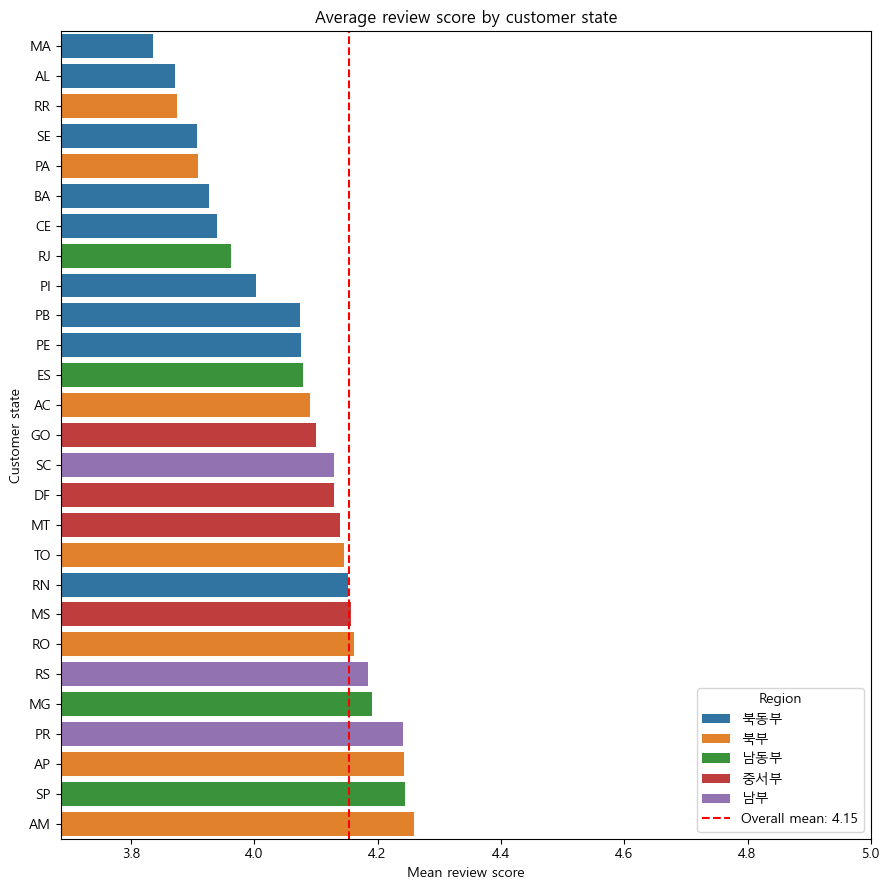

In [10]:
overall_review_mean = order_df[TARGET].mean()
state_plot_df = state_review_summary_df.sort_values("mean_review", ascending=True).copy()

plt.figure(figsize=(9, 9))
sns.barplot(
    data=state_plot_df,
    x="mean_review",
    y="state",
    hue="region",
    dodge=False,
)
plt.axvline(
    overall_review_mean,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Overall mean: {overall_review_mean:.2f}",
)
plt.title("Average review score by customer state")
plt.xlabel("Mean review score")
plt.ylabel("Customer state")
plt.xlim(max(0, state_plot_df["mean_review"].min() - 0.15), 5)
plt.legend(title="Region", loc="lower right")
plt.tight_layout()

## 10. 권역별 평점 차이 확인

`customer_region` 기준으로 권역별 평균 평점을 확인합니다. 리뷰는 고객이 남기는 평가이므로, 권역별 평점 요약은 고객 도착지 기준으로 해석합니다. 주별 표보다 더 큰 지역 단위로 묶기 때문에 표본 수가 안정적이고, 지역별 물류 조건 차이를 큰 흐름으로 보기 좋습니다.

검정은 권역 간 리뷰 점수 분포 차이를 Kruskal-Wallis 검정으로 확인합니다. 사후검정은 권역 쌍별 Mann-Whitney U 검정을 수행한 뒤 FDR 방식으로 p-value를 보정합니다.

In [11]:
REGION_COLS = [col for col in ["customer_region"] if col in order_df.columns]

region_test_rows = []
region_summary_frames = []

for region_col in REGION_COLS:
    pair = order_df[[TARGET, region_col]].dropna().copy()
    counts = pair[region_col].value_counts()
    valid_regions = counts[counts >= MIN_GROUP_N].index
    pair = pair[pair[region_col].isin(valid_regions)]
    groups = [g[TARGET].to_numpy() for _, g in pair.groupby(region_col)]

    if pair[region_col].nunique() >= 2:
        h_stat, p_value = stats.kruskal(*groups)
        n = len(pair)
        k = pair[region_col].nunique()
        epsilon_squared = (h_stat - k + 1) / (n - k) if n > k else np.nan
        region_test_rows.append({
            "region_role": region_col,
            "n": n,
            "regions_tested": k,
            "kruskal_h": h_stat,
            "kruskal_p": p_value,
            "epsilon_squared": epsilon_squared,
        })

    summary = (
        pair.groupby(region_col)[TARGET]
        .agg(n="size", mean_review="mean", median_review="median", std_review="std")
        .reset_index()
        .rename(columns={region_col: "region"})
    )
    summary["region_role"] = region_col
    summary["mean_diff_from_overall"] = summary["mean_review"] - pair[TARGET].mean()
    region_summary_frames.append(summary)

region_test_df = pd.DataFrame(region_test_rows)
if not region_test_df.empty:
    region_test_df["kruskal_p_fdr"] = fdr_bh(region_test_df["kruskal_p"])
    region_test_df["significant_fdr_0_05"] = region_test_df["kruskal_p_fdr"] < 0.05

region_review_summary_df = pd.concat(region_summary_frames, ignore_index=True)
region_review_summary_df = region_review_summary_df[
    ["region", "n", "mean_review", "median_review", "std_review", "region_role", "mean_diff_from_overall"]
]
region_review_summary_df = region_review_summary_df.sort_values(
    ["region_role", "mean_review"], ascending=[True, False]
)
region_posthoc_df = pairwise_mannwhitney_posthoc(order_df, "customer_region", TARGET, MIN_GROUP_N)

display(region_test_df)
display(region_review_summary_df)
display(region_posthoc_df)

,region_role,n,regions_tested,kruskal_h,kruskal_p,epsilon_squared,kruskal_p_fdr,significant_fdr_0_05
0,customer_region,94443,5,237.4153,0.0000,0.0025,0.0000,True


,region,n,mean_review,median_review,std_review,region_role,mean_diff_from_overall
1,남부,13528,4.1903,5.0000,1.2475,customer_region,0.0362
0,남동부,64808,4.1778,5.0000,1.2725,customer_region,0.0237
4,중서부,5499,4.1245,5.0000,1.2928,customer_region,-0.0296
3,북부,1759,4.0279,5.0000,1.3406,customer_region,-0.1262
2,북동부,8849,3.9688,5.0000,1.3942,customer_region,-0.1853


,group_col,group_a,group_b,n_a,n_b,mean_a,mean_b,mean_diff_a_minus_b,median_a,median_b,mannwhitney_u,mannwhitney_p,mannwhitney_p_fdr,significant_fdr_0_05,abs_mean_diff
4,customer_region,남부,북동부,13528,8849,4.1903,3.9688,0.2215,5.0000,5.0000,"64,817,941.5000",0.0000,0.0000,True,0.2215
1,customer_region,남동부,북동부,64808,8849,4.1778,3.9688,0.2090,5.0000,5.0000,"310,527,951.0000",0.0000,0.0000,True,0.2090
5,customer_region,남부,북부,13528,1759,4.1903,4.0279,0.1625,5.0000,5.0000,"12,688,654.5000",0.0000,0.0000,True,0.1625
8,customer_region,북동부,중서부,8849,5499,3.9688,4.1245,-0.1557,5.0000,5.0000,"22,942,963.0000",0.0000,0.0000,True,0.1557
2,customer_region,남동부,북부,64808,1759,4.1778,4.0279,0.1499,5.0000,5.0000,"60,793,747.5000",0.0000,0.0000,True,0.1499
9,customer_region,북부,중서부,1759,5499,4.0279,4.1245,-0.0966,5.0000,5.0000,"4,641,565.5000",0.0046,0.0058,True,0.0966
6,customer_region,남부,중서부,13528,5499,4.1903,4.1245,0.0658,5.0000,5.0000,"38,166,119.0000",0.0014,0.0020,True,0.0658
3,customer_region,남동부,중서부,64808,5499,4.1778,4.1245,0.0533,5.0000,5.0000,"182,942,976.0000",0.0002,0.0003,True,0.0533
7,customer_region,북동부,북부,8849,1759,3.9688,4.0279,-0.0590,5.0000,5.0000,"7,648,154.5000",0.2105,0.2339,False,0.0590
0,customer_region,남동부,남부,64808,13528,4.1778,4.1903,-0.0125,5.0000,5.0000,"438,723,195.5000",0.8636,0.8636,False,0.0125


### 권역별 평균 평점 시각화

고객 권역 기준 평균 평점을 시각화합니다. 빨간 점선은 전체 평균 평점입니다.

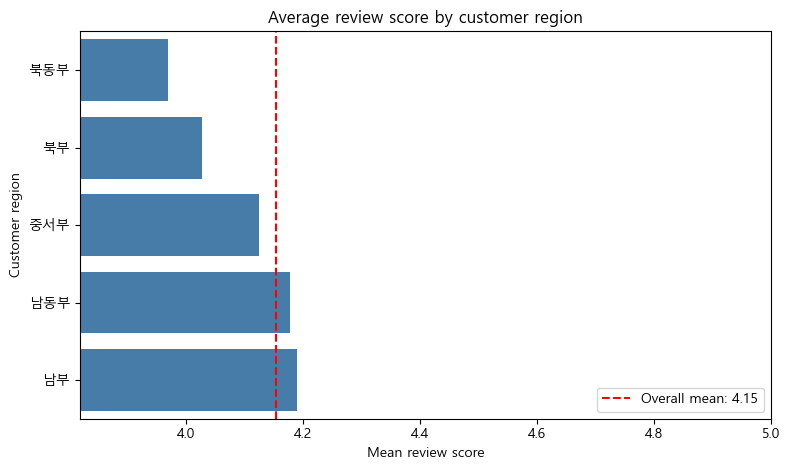

In [12]:
region_plot_df = region_review_summary_df.sort_values("mean_review", ascending=True).copy()

plt.figure(figsize=(8, 4.8))
sns.barplot(
    data=region_plot_df,
    x="mean_review",
    y="region",
    color="#377eb8",
)
plt.axvline(
    overall_review_mean,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Overall mean: {overall_review_mean:.2f}",
)
plt.title("Average review score by customer region")
plt.xlabel("Mean review score")
plt.ylabel("Customer region")
plt.xlim(max(0, region_plot_df["mean_review"].min() - 0.15), 5)
plt.legend(loc="lower right")
plt.tight_layout()

## 11. 주요 상관관계 시각화

상관계수 절댓값 기준 상위 변수를 막대그래프로 확인합니다. 물류 변수는 별도 색상으로 표시합니다.

빨간 점선은 `|Spearman r| = 0.10`입니다. 이번 데이터는 주문 단위 표본이 약 9만 건으로 매우 커서, 아주 작은 상관도 p-value나 FDR 보정 기준으로는 유의하게 나올 수 있습니다. 따라서 통계적 유의성만으로 해석하지 않고, 효과 크기 기준을 함께 둡니다. 일반적으로 `|r| < 0.10`은 효과가 매우 작거나 실무적 의미가 약한 관계로 보고, `|r| >= 0.10`부터는 약하지만 해석 가능한 관계 후보로 봅니다. 이 기준은 Cohen의 효과크기 관례에서 작은 효과를 대략 `r = 0.10` 수준으로 보는 해석과도 맞닿아 있습니다.

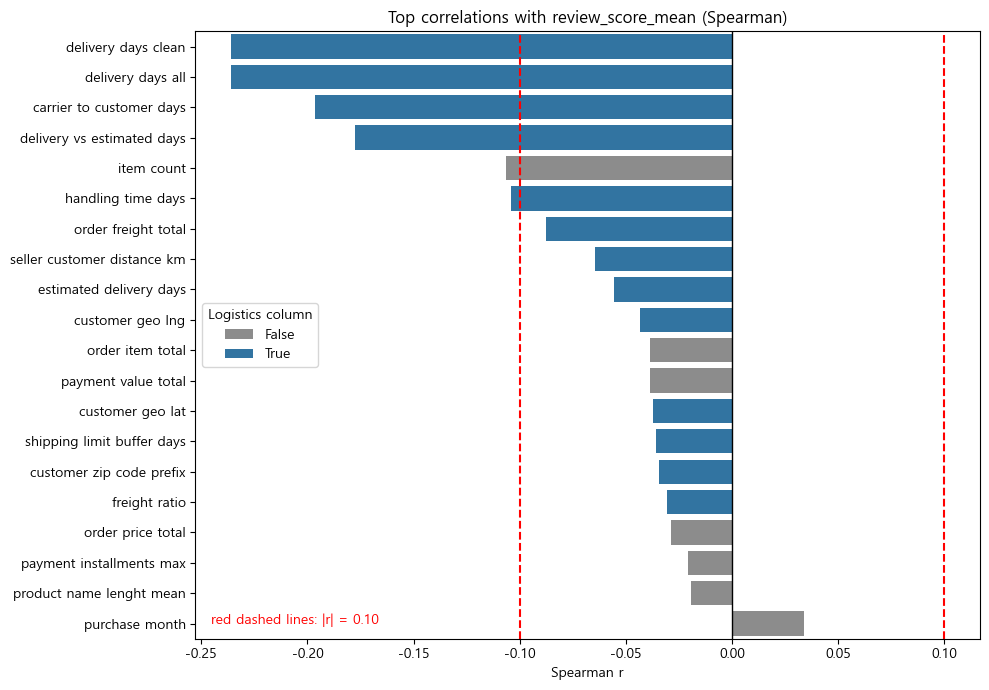

In [13]:
MEANINGFUL_CORR_THRESHOLD = 0.10

top_corr = corr_df.head(20).copy()
top_corr["label"] = top_corr["column"].str.replace("_", " ")

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_corr.sort_values("spearman_r"),
    x="spearman_r",
    y="label",
    hue="is_logistics",
    dodge=False,
    palette={True: "#1f77b4", False: "#8c8c8c"},
)
plt.axvline(0, color="black", linewidth=1)
plt.axvline(MEANINGFUL_CORR_THRESHOLD, color="red", linestyle="--", linewidth=1.5)
plt.axvline(-MEANINGFUL_CORR_THRESHOLD, color="red", linestyle="--", linewidth=1.5)
plt.text(
    0.02,
    0.02,
    "red dashed lines: |r| = 0.10",
    transform=plt.gca().transAxes,
    color="red",
    ha="left",
    va="bottom",
    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85},
)
plt.title("Top correlations with review_score_mean (Spearman)")
plt.xlabel("Spearman r")
plt.ylabel("")
plt.legend(title="Logistics column")
plt.tight_layout()

## 12. 물류 변수 중심 해석용 요약

아래 셀은 물류 수치형 변수 중 유의하고 절대 상관계수가 큰 항목, Boolean 변수 검정 결과, 범주형 변수 검정 결과를 함께 출력합니다.

In [14]:
print("[물류 수치형 변수: Spearman 상관, FDR 보정]")
display(
    logistics_corr_df[
        ["column", "n", "spearman_r", "spearman_p_fdr", "significant_fdr_0_05", "pearson_r"]
    ].sort_values("spearman_r", key=lambda s: s.abs(), ascending=False)
)

print("\n[물류 Boolean 변수: Mann-Whitney U 검정, FDR 보정]")
display(binary_test_df if "binary_test_df" in globals() else pd.DataFrame())

print("\n[물류 범주형 변수: Kruskal-Wallis 검정, FDR 보정]")
display(cat_test_df if "cat_test_df" in globals() else pd.DataFrame())

print("\n[주별 평점 차이: Kruskal-Wallis 검정, FDR 보정]")
display(state_test_df if "state_test_df" in globals() else pd.DataFrame())
display(state_posthoc_df.head(30) if "state_posthoc_df" in globals() else pd.DataFrame())

print("\n[권역별 평점 차이: Kruskal-Wallis 검정, FDR 보정]")
display(region_test_df if "region_test_df" in globals() else pd.DataFrame())
display(region_posthoc_df if "region_posthoc_df" in globals() else pd.DataFrame())

[물류 수치형 변수: Spearman 상관, FDR 보정]


,column,n,spearman_r,spearman_p_fdr,significant_fdr_0_05,pearson_r
4,delivery_days_clean,94443,-0.2360,0.0000,True,-0.3355
5,delivery_days_all,94443,-0.2360,0.0000,True,-0.3355
28,carrier_to_customer_days,94443,-0.1963,0.0000,True,-0.3016
30,delivery_vs_estimated_days,94443,-0.1777,0.0000,True,-0.2691
27,handling_time_days,94443,-0.1039,0.0000,True,-0.1579
16,order_freight_total,94443,-0.0874,0.0000,True,-0.0890
33,seller_customer_distance_km,93975,-0.0643,0.0000,True,-0.0590
29,estimated_delivery_days,94443,-0.0554,0.0000,True,-0.0522
9,customer_geo_lng,94185,-0.0434,0.0000,True,-0.0499
8,customer_geo_lat,94185,-0.0374,0.0000,True,-0.0429



[물류 Boolean 변수: Mann-Whitney U 검정, FDR 보정]


,column,n_0,n_1,mean_review_0,mean_review_1,mean_diff_1_minus_0,mannwhitney_p,welch_t_p,cohens_d,mannwhitney_p_fdr,significant_fdr_0_05
0,is_late,86816,7627,4.2938,2.5642,-1.7296,0.0000,0.0000,-1.4468,0.0000,True
1,seller_customer_same_state,60469,33974,4.0937,4.2615,0.1678,0.0000,0.0000,0.1309,0.0000,True
2,seller_state_geo_mismatch,93888,555,4.1532,4.2973,0.1441,0.0142,0.0039,0.1121,0.0142,True
3,is_seller_geo_unreliable,93888,555,4.1532,4.2973,0.1441,0.0142,0.0039,0.1121,0.0142,True



[물류 범주형 변수: Kruskal-Wallis 검정, FDR 보정]


...

,state_role,n,states_tested,kruskal_h,kruskal_p,epsilon_squared,kruskal_p_fdr,significant_fdr_0_05
0,customer_state,94443,27,578.1290,0.0000,0.0058,0.0000,True


,group_col,group_a,group_b,n_a,n_b,mean_a,mean_b,mean_diff_a_minus_b,median_a,median_b,mannwhitney_u,mannwhitney_p,mannwhitney_p_fdr,significant_fdr_0_05,abs_mean_diff
57,customer_state,AM,MA,143,699,4.2587,3.8362,0.4225,5.0000,4.0000,"57,986.5000",0.0011,0.0055,True,0.4225
213,customer_state,MA,SP,699,39677,3.8362,4.2444,-0.4082,4.0000,5.0000,"11,768,189.5000",0.0000,0.0000,True,0.4082
205,customer_state,MA,PR,699,4821,3.8362,4.2406,-0.4044,4.0000,5.0000,"1,435,059.5000",0.0000,0.0000,True,0.4044
26,customer_state,AL,AM,390,143,3.8718,4.2587,-0.3869,4.5000,5.0000,"23,786.5000",0.0044,0.0175,True,0.3869
49,customer_state,AL,SP,390,39677,3.8718,4.2444,-0.3726,4.5000,5.0000,"6,668,305.0000",0.0000,0.0000,True,0.3726
41,customer_state,AL,PR,390,4821,3.8718,4.2406,-0.3688,4.5000,5.0000,"813,215.5000",0.0000,0.0000,True,0.3688
198,customer_state,MA,MG,699,11117,3.8362,4.1906,-0.3544,4.0000,5.0000,"3,378,293.0000",0.0000,0.0000,True,0.3544
61,customer_state,AM,PA,143,923,4.2587,3.9090,0.3497,5.0000,5.0000,"74,851.5000",0.0048,0.0185,True,0.3497
210,customer_state,MA,RS,699,5242,3.8362,4.1844,-0.3482,4.0000,5.0000,"1,598,073.0000",0.0000,0.0000,True,0.3482
348,customer_state,SE,SP,332,39677,3.9066,4.2444,-0.3378,5.0000,5.0000,"5,830,071.0000",0.0000,0.0003,True,0.3378



[권역별 평점 차이: Kruskal-Wallis 검정, FDR 보정]


,region_role,n,regions_tested,kruskal_h,kruskal_p,epsilon_squared,kruskal_p_fdr,significant_fdr_0_05
0,customer_region,94443,5,237.4153,0.0000,0.0025,0.0000,True


,group_col,group_a,group_b,n_a,n_b,mean_a,mean_b,mean_diff_a_minus_b,median_a,median_b,mannwhitney_u,mannwhitney_p,mannwhitney_p_fdr,significant_fdr_0_05,abs_mean_diff
4,customer_region,남부,북동부,13528,8849,4.1903,3.9688,0.2215,5.0000,5.0000,"64,817,941.5000",0.0000,0.0000,True,0.2215
1,customer_region,남동부,북동부,64808,8849,4.1778,3.9688,0.2090,5.0000,5.0000,"310,527,951.0000",0.0000,0.0000,True,0.2090
5,customer_region,남부,북부,13528,1759,4.1903,4.0279,0.1625,5.0000,5.0000,"12,688,654.5000",0.0000,0.0000,True,0.1625
8,customer_region,북동부,중서부,8849,5499,3.9688,4.1245,-0.1557,5.0000,5.0000,"22,942,963.0000",0.0000,0.0000,True,0.1557
2,customer_region,남동부,북부,64808,1759,4.1778,4.0279,0.1499,5.0000,5.0000,"60,793,747.5000",0.0000,0.0000,True,0.1499
9,customer_region,북부,중서부,1759,5499,4.0279,4.1245,-0.0966,5.0000,5.0000,"4,641,565.5000",0.0046,0.0058,True,0.0966
6,customer_region,남부,중서부,13528,5499,4.1903,4.1245,0.0658,5.0000,5.0000,"38,166,119.0000",0.0014,0.0020,True,0.0658
3,customer_region,남동부,중서부,64808,5499,4.1778,4.1245,0.0533,5.0000,5.0000,"182,942,976.0000",0.0002,0.0003,True,0.0533
7,customer_region,북동부,북부,8849,1759,3.9688,4.0279,-0.0590,5.0000,5.0000,"7,648,154.5000",0.2105,0.2339,False,0.0590
0,customer_region,남동부,남부,64808,13528,4.1778,4.1903,-0.0125,5.0000,5.0000,"438,723,195.5000",0.8636,0.8636,False,0.0125


## 13. 결과 저장

상관분석과 검정 결과를 CSV로 저장합니다.

In [15]:
OUTPUT_DIR = ROOT / "notebooks" / "Distribution_hub" / "SG" / "Logistics_folder" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

corr_df.to_csv(OUTPUT_DIR / "review_score_numeric_correlations.csv", index=False, encoding="utf-8-sig")
logistics_corr_df.to_csv(OUTPUT_DIR / "review_score_logistics_numeric_correlations.csv", index=False, encoding="utf-8-sig")
binary_test_df.to_csv(OUTPUT_DIR / "review_score_logistics_binary_tests.csv", index=False, encoding="utf-8-sig")
cat_test_df.to_csv(OUTPUT_DIR / "review_score_logistics_categorical_tests.csv", index=False, encoding="utf-8-sig")
state_test_df.to_csv(OUTPUT_DIR / "review_score_state_tests.csv", index=False, encoding="utf-8-sig")
state_review_summary_df.to_csv(OUTPUT_DIR / "review_score_state_summary.csv", index=False, encoding="utf-8-sig")
state_posthoc_df.to_csv(OUTPUT_DIR / "review_score_state_posthoc_pairwise.csv", index=False, encoding="utf-8-sig")
region_test_df.to_csv(OUTPUT_DIR / "review_score_region_tests.csv", index=False, encoding="utf-8-sig")
region_review_summary_df.to_csv(OUTPUT_DIR / "review_score_region_summary.csv", index=False, encoding="utf-8-sig")
region_posthoc_df.to_csv(OUTPUT_DIR / "review_score_region_posthoc_pairwise.csv", index=False, encoding="utf-8-sig")

print(f"saved outputs to: {OUTPUT_DIR}")

saved outputs to: c:\team-oldest-olist-analysis\notebooks\Distribution_hub\SG\Logistics_folder\outputs
